# Assignment 04 · Miền `customer_comments` — Notebook 02
# Mạng tích chập một chiều hiện thực bằng **PyTorch**

- **Sinh viên:** Nguyễn Duy Nghĩa · **Mã sinh viên:** B23DCCN600 · **Lớp:** D23CTPM01
- **Học phần:** Phát triển các Hệ thống Thông minh · **Giảng viên:** PGS.TS Trần Đình Quế
- **Học kỳ:** Học kỳ 1 năm học 2026 – 2027
- **Assignment 04:** Convolutional Neural Networks — From Mathematical Convolution to NumPy, PyTorch and TensorFlow
- **Miền dữ liệu:** `customer_comments` — bình luận đánh giá sản phẩm thời trang nữ (Women's E-Commerce Clothing Reviews)

---

## 1. Mục tiêu của notebook

Notebook 01 đã xây dựng toàn bộ mạng bằng NumPy thuần, tự viết lượt truyền ngược và tự kiểm chứng
gradient. Notebook này hiện thực **đúng cùng một kiến trúc** bằng PyTorch nhằm ba mục đích:

1. **Đối chứng tính đúng đắn.** Nếu mô hình NumPy đạt chỉ số tương đương với PyTorch trên cùng dữ
   liệu và cùng siêu tham số, đó là bằng chứng độc lập cho thấy hiện thực thủ công không có lỗi.
2. **Đối chứng hiệu năng.** So sánh thời gian huấn luyện cho thấy cái giá phải trả khi từ bỏ các
   nhân tính toán đã tối ưu của thư viện.
3. **Làm rõ ranh giới giữa "hiểu" và "dùng".** Mỗi tầng PyTorch dưới đây được đặt cạnh công thức
   toán tương ứng đã dẫn ở notebook 01, để thấy `nn.Conv1d` không phải hộp đen mà chính là phép
   tương quan chéo đã tính tay.

### Kiến trúc (giữ nguyên theo `CONTRACT.md`, Mục 4)

$$
\text{tokens}(50) \;\to\; \text{Embedding}(5000, 100) \;\to\; \text{Conv1D}(32, K{=}3) \;\to\;
\text{ReLU} \;\to\; \text{GlobalMaxPool1D} \;\to\; \text{Dense}(1) \;\to\; \sigma
$$

### Một khác biệt kỹ thuật cần lưu ý ngay

`nn.Conv1d` của PyTorch mong đợi tensor theo bố cục **(batch, kênh, độ dài)**, trong khi
`nn.Embedding` trả về **(batch, độ dài, kênh)**. Vì vậy giữa hai tầng bắt buộc phải có một phép
`transpose(1, 2)`. Đây là lỗi thường gặp nhất khi ghép hai tầng này; nếu quên, mô hình vẫn chạy
nhưng đang tích chập dọc theo chiều nhúng thay vì dọc theo chuỗi từ.

## 2. Nhập thư viện và cố định seed

In [1]:
import os, re, json, time, math, collections
import numpy as np
import pandas as pd
import matplotlib

import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             classification_report)

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
torch.use_deterministic_algorithms(False)

plt.rcParams["font.sans-serif"] = ["Segoe UI", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["savefig.facecolor"] = "white"

VOCAB_SIZE, MAX_LEN, EMBED_DIM = 5000, 50, 100
N_FILTERS, KERNEL = 32, 3
DATA_PATH  = "../data/womens_ecommerce_reviews.csv"
FIG_DIR    = "../reports/figures"
REPORT_DIR = "../reports"
os.makedirs(FIG_DIR, exist_ok=True); os.makedirs(REPORT_DIR, exist_ok=True)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("PyTorch    :", torch.__version__)
print("Thiết bị   :", DEVICE, "(hợp đồng quy định chạy trên CPU)")
print("Số luồng   :", torch.get_num_threads())
print("Seed       :", RANDOM_SEED)

PyTorch    : 2.9.1+cpu
Thiết bị   : cpu (hợp đồng quy định chạy trên CPU)
Số luồng   : 16
Seed       : 42


## 3. Nạp dữ liệu và tiền xử lý

Phần này lặp lại **nguyên văn** quy trình tiền xử lý của notebook 01. Việc lặp lại là có chủ đích:
ba notebook phải chạy độc lập được, và điều kiện tiên quyết để so sánh ba cách hiện thực là chúng
nhìn thấy **cùng một ma trận chỉ số và cùng một phép chia tập**. Vì mọi bước đều tất định và cùng
dùng `random_state=42`, ba notebook tạo ra ba tập dữ liệu giống hệt nhau.

### 3.1 Quy trình tiền xử lý bắt buộc

Hợp đồng tích hợp (`CONTRACT.md`, Mục 3) quy định quy trình tiền xử lý **bắt buộc** cho miền
`customer_comments`, và báo cáo tuân thủ nguyên văn:

1. `dropna(subset=['Review Text','Recommended IND'])`: loại các bản ghi thiếu nội dung hoặc thiếu nhãn.
2. Hạ toàn bộ văn bản về chữ thường.
3. Tách token bằng biểu thức chính quy `re.findall(r'[a-zA-Z]+', text)`.
4. Từ điển kích thước `VOCAB_SIZE = 5000` với hai token đặc biệt `<PAD>` = 0 và `<UNK>` = 1.
5. Cắt hoặc đệm mọi chuỗi về độ dài cố định `MAX_LEN = 50`.
6. Chiều không gian nhúng `EMBED_DIM = 100`.

**Tại sao lại làm như vậy?** Báo cáo giải thích từng lựa chọn thay vì chỉ liệt kê thao tác:

- *Hạ chữ thường và chỉ giữ ký tự chữ cái.* Mục tiêu của bài toán là phân loại quan điểm, không phải
  phân tích chính tả. Nếu giữ nguyên dạng chữ thì `"Love"`, `"love"` và `"LOVE"` bị coi là ba token
  khác nhau, làm phân mảnh vô ích ngân sách 5 000 từ vựng. Biểu thức `[a-zA-Z]+` đồng thời loại bỏ
  chữ số, dấu câu và emoji, vốn là những thành phần mang rất ít thông tin quan điểm trong tập dữ liệu này
  nhưng lại chiếm chỗ trong từ điển.
- *Giới hạn từ điển ở 5 000 từ.* Ma trận nhúng có kích thước $|V| \times d$. Với $d = 100$, mỗi
  1 000 từ tăng thêm tương ứng 100 000 tham số. Giới hạn 5 000 giữ mô hình ở mức nửa triệu tham số,
  vừa đủ nhỏ để huấn luyện bằng NumPy thuần trên CPU trong ngân sách thời gian cho phép. Các từ
  hiếm rơi vào `<UNK>`; đây là hành vi mong muốn vì từ xuất hiện một hai lần không đủ dữ liệu để
  học được một vector nhúng có ý nghĩa.
- *Từ điển chỉ được xây trên tập huấn luyện.* Đây là điểm mấu chốt về tính trung thực của phép đánh
  giá. Nếu đếm tần suất trên toàn bộ dữ liệu, thông tin từ tập kiểm tra sẽ rò rỉ ngược vào giai đoạn
  thiết kế mô hình (data leakage) và chỉ số cuối cùng sẽ lạc quan hơn thực tế.
- *Đệm về độ dài cố định 50.* Phép tích chập một chiều được vector hóa theo lô đòi hỏi mọi mẫu trong
  lô có cùng độ dài. Token `<PAD>` = 0 được gán vector nhúng khởi tạo bằng 0 và **gradient của nó
  luôn bị ép về 0** sau mỗi bước, nên phần đệm không đóng góp tín hiệu học.


In [2]:
df_raw = pd.read_csv(DATA_PATH)
N_RAW = len(df_raw)
df = df_raw.dropna(subset=["Review Text", "Recommended IND"]).reset_index(drop=True)
N_CLEAN = len(df)
labels = df["Recommended IND"].astype(int).values

def tokenize(text: str):
    return re.findall(r"[a-zA-Z]+", text.lower())

tokens_all  = [tokenize(t) for t in df["Review Text"].astype(str)]
doc_lengths = np.array([len(t) for t in tokens_all])

idx_all = np.arange(N_CLEAN)
idx_tmp, idx_test = train_test_split(idx_all, test_size=0.15,
                                     stratify=labels, random_state=RANDOM_SEED)
idx_train, idx_val = train_test_split(idx_tmp, test_size=0.1765,
                                      stratify=labels[idx_tmp], random_state=RANDOM_SEED)
N_TRAIN, N_VAL, N_TEST = len(idx_train), len(idx_val), len(idx_test)

counter = collections.Counter(w for i in idx_train for w in tokens_all[i])
word2id = {"<PAD>": 0, "<UNK>": 1}
for w, _ in counter.most_common(VOCAB_SIZE - 2):
    word2id[w] = len(word2id)

def encode(token_list):
    X = np.zeros((len(token_list), MAX_LEN), dtype=np.int64)
    for i, toks in enumerate(token_list):
        ids = [word2id.get(w, 1) for w in toks[:MAX_LEN]]
        X[i, :len(ids)] = ids
    return X

X_train = encode([tokens_all[i] for i in idx_train])
X_val   = encode([tokens_all[i] for i in idx_val])
X_test  = encode([tokens_all[i] for i in idx_test])
y_train = labels[idx_train].astype(np.float32)
y_val   = labels[idx_val].astype(np.float32)
y_test  = labels[idx_test].astype(np.float32)

print(f"Bản ghi gốc            : {N_RAW:,}")
print(f"Bản ghi sau làm sạch   : {N_CLEAN:,}  (mất {N_RAW-N_CLEAN:,} bản ghi thiếu nội dung)")
print(f"Độ dài trung bình      : {doc_lengths.mean():.2f} token "
      f"(trung vị {np.median(doc_lengths):.0f})")
print(f"Kích thước từ điển     : {len(word2id):,}")
print(f"Chia tập               : train {N_TRAIN:,} / val {N_VAL:,} / test {N_TEST:,}")
print(f"Tỉ lệ nhãn 1 mỗi tập   : {y_train.mean():.4f} / {y_val.mean():.4f} / {y_test.mean():.4f}")
print(f"Ma trận chỉ số         : {X_train.shape}, kiểu {X_train.dtype}")

Bản ghi gốc            : 23,486
Bản ghi sau làm sạch   : 22,641  (mất 845 bản ghi thiếu nội dung)
Độ dài trung bình      : 60.77 token (trung vị 60)
Kích thước từ điển     : 5,000
Chia tập               : train 15,847 / val 3,397 / test 3,397
Tỉ lệ nhãn 1 mỗi tập   : 0.8188 / 0.8190 / 0.8190
Ma trận chỉ số         : (15847, 50), kiểu int64


**Diễn giải.** Các con số trùng khớp **từng chữ số** với notebook 01: 23 486 bản ghi gốc, 22 641 bản
ghi sau làm sạch (mất đúng 845 bản ghi thiếu nội dung), độ dài trung bình 60.77 token, từ điển 5 000
từ, chia tập 15 847 / 3 397 / 3 397 với tỉ lệ nhãn 1 lần lượt 0.8188 / 0.8190 / 0.8190.

Sự trùng khớp này không phải ngẫu nhiên mà là điều kiện tiên quyết của toàn bộ phép so sánh ba
framework: nếu hai notebook nhìn thấy hai tập dữ liệu khác nhau thì mọi chênh lệch chỉ số về sau sẽ
không thể quy cho framework. Nó được bảo đảm nhờ ba yếu tố: quy trình tiền xử lý hoàn toàn tất định,
`random_state=42` trong cả hai lần `train_test_split`, và việc từ điển được xây bằng
`Counter.most_common` trên cùng một tập chỉ số huấn luyện.

Điểm khác biệt kỹ thuật duy nhất là kiểu dữ liệu của ma trận chỉ số: `int64` ở đây, vì
`nn.Embedding` của PyTorch yêu cầu chỉ số kiểu `torch.long`. Notebook 03 sẽ dùng `int32` theo yêu cầu
của Keras. Đây là khác biệt về biểu diễn bộ nhớ, không phải về nội dung dữ liệu.

### 3.2 Đóng gói dữ liệu vào `DataLoader`

`TensorDataset` + `DataLoader` thay thế cho vòng lặp cắt lô thủ công ở notebook 01. Tham số
`shuffle=True` được đặt cho tập huấn luyện (xáo trộn lại ở mỗi epoch, tương đương với
`rng.permutation` của notebook 01) và `shuffle=False` cho tập kiểm định và kiểm tra. Bộ sinh số ngẫu
nhiên của `DataLoader` được gieo tường minh để thứ tự lô có thể tái lập.

In [3]:
BATCH_SIZE = 64

def make_loader(X, y, shuffle):
    ds = TensorDataset(torch.from_numpy(X), torch.from_numpy(y))
    g = torch.Generator(); g.manual_seed(RANDOM_SEED)
    return DataLoader(ds, batch_size=BATCH_SIZE, shuffle=shuffle, generator=g if shuffle else None)

train_loader = make_loader(X_train, y_train, True)
val_loader   = make_loader(X_val,   y_val,   False)
test_loader  = make_loader(X_test,  y_test,  False)
print(f"Số lô mỗi epoch: train {len(train_loader)}, val {len(val_loader)}, test {len(test_loader)}")

Số lô mỗi epoch: train 248, val 54, test 54


## 4. Đối chiếu từng tầng PyTorch với công thức toán

| Tầng PyTorch | Công thức tương ứng | Ghi chú hiện thực |
|---|---|---|
| `nn.Embedding(5000, 100, padding_idx=0)` | $\mathbf{e}_{b,l,:} = E_{t_{b,l},:}$ | `padding_idx=0` ép hàng `<PAD>` bằng 0 và **không nhận gradient**, đúng như thao tác `dW[0] = 0` viết tay ở notebook 01 |
| `x.transpose(1, 2)` | đổi bố cục $(B,L,D) \to (B,D,L)$ | bắt buộc vì `nn.Conv1d` coi chiều thứ hai là kênh |
| `nn.Conv1d(100, 32, 3)` | $z_{b,c,l} = \sum_{d}\sum_{j} e_{b,d,l+j} W_{c,d,j} + b_c$ | mặc định `padding=0`, `stride=1` nên $L' = 50 - 3 + 1 = 48$ |
| `nn.ReLU()` | $a = \max(0, z)$ | |
| `nn.AdaptiveMaxPool1d(1)` | $p_{b,c} = \max_{l} a_{b,c,l}$ | kích thước đầu ra 1 chính là gộp cực đại toàn cục |
| `nn.Linear(32, 1)` | $u = pW_2 + b_2$ | |
| `nn.BCEWithLogitsLoss` | $\mathcal{L} = -\frac{1}{B}\sum [y\log\sigma(u) + (1-y)\log(1-\sigma(u))]$ | nhận **logit** chứ không nhận xác suất |

**Vì sao dùng `BCEWithLogitsLoss` thay vì `Sigmoid` rồi `BCELoss`?** Đây chính là thủ thuật ghép hai
tầng đã chứng minh ở Mục 6.5 của notebook 01: gộp sigmoid vào hàm mất mát cho phép PyTorch áp dụng
biến đổi *log-sum-exp* ổn định và rút gọn đạo hàm thành $\partial \mathcal{L}/\partial u = (\sigma(u) - y)/B$.
Nếu tách rời, khi $\sigma(u)$ tiến sát 0 hoặc 1 thì $\log$ sẽ tràn số âm vô cùng.

Khởi tạo trọng số cũng được đặt tường minh để khớp với notebook 01: nhúng lấy từ phân phối chuẩn
$\mathcal{N}(0, 0.05^2)$, hai tầng còn lại dùng Glorot uniform.

In [4]:
class TextCNNTorch(nn.Module):
    """Bản PyTorch của cùng một kiến trúc đã hiện thực bằng NumPy ở notebook 01."""

    def __init__(self, vocab_size=VOCAB_SIZE, embed_dim=EMBED_DIM,
                 n_filters=N_FILTERS, kernel=KERNEL):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.conv      = nn.Conv1d(embed_dim, n_filters, kernel_size=kernel)
        self.relu      = nn.ReLU()
        self.pool      = nn.AdaptiveMaxPool1d(1)      # gộp cực đại toàn cục
        self.fc        = nn.Linear(n_filters, 1)
        self._init_weights()

    def _init_weights(self):
        nn.init.normal_(self.embedding.weight, mean=0.0, std=0.05)
        with torch.no_grad():
            self.embedding.weight[0].zero_()          # hàng <PAD>
        nn.init.xavier_uniform_(self.conv.weight); nn.init.zeros_(self.conv.bias)
        nn.init.xavier_uniform_(self.fc.weight);   nn.init.zeros_(self.fc.bias)

    def forward(self, x):                             # x: (B, L) số nguyên
        e = self.embedding(x)                         # (B, L, D)
        e = e.transpose(1, 2)                         # (B, D, L)  <- bắt buộc cho Conv1d
        z = self.conv(e)                              # (B, C, L')
        a = self.relu(z)
        p = self.pool(a).squeeze(-1)                  # (B, C)
        return self.fc(p).squeeze(-1)                 # (B,) logit


torch.manual_seed(RANDOM_SEED)
model = TextCNNTorch().to(DEVICE)

print(model)
print()
print("Bảng đếm tham số (tương đương torchinfo summary)")
print("=" * 74)
print(f"{'Tên tham số':<26}{'Kích thước':<22}{'Số phần tử':>12}{'Học?':>10}")
print("-" * 74)
total, trainable = 0, 0
for name, prm in model.named_parameters():
    total += prm.numel()
    trainable += prm.numel() if prm.requires_grad else 0
    print(f"{name:<26}{str(tuple(prm.shape)):<22}{prm.numel():>12,}{str(prm.requires_grad):>10}")
print("-" * 74)
N_PARAMS = int(total)
print(f"{'TỔNG':<26}{'':<22}{total:>12,}")
print(f"{'Có thể học':<26}{'':<22}{trainable:>12,}")
print(f"{'Ước lượng bộ nhớ':<26}{'':<22}{total*4/1024**2:>11.2f} MB (float32)")
print()
with torch.no_grad():
    demo = torch.from_numpy(X_train[:4])
    e  = model.embedding(demo); et = e.transpose(1, 2)
    z  = model.conv(et); a = model.relu(z); p = model.pool(a).squeeze(-1)
    lo = model.fc(p).squeeze(-1)
print("Lần vết kích thước tensor qua từng tầng:")
print(f"  đầu vào              : {tuple(demo.shape)}")
print(f"  sau Embedding        : {tuple(e.shape)}")
print(f"  sau transpose(1,2)   : {tuple(et.shape)}")
print(f"  sau Conv1d(100,32,3) : {tuple(z.shape)}")
print(f"  sau AdaptiveMaxPool  : {tuple(p.shape)}")
print(f"  logit đầu ra         : {tuple(lo.shape)} -> {torch.sigmoid(lo).numpy().round(4)}")

TextCNNTorch(
  (embedding): Embedding(5000, 100, padding_idx=0)
  (conv): Conv1d(100, 32, kernel_size=(3,), stride=(1,))
  (relu): ReLU()
  (pool): AdaptiveMaxPool1d(output_size=1)
  (fc): Linear(in_features=32, out_features=1, bias=True)
)

Bảng đếm tham số (tương đương torchinfo summary)
Tên tham số               Kích thước              Số phần tử      Học?
--------------------------------------------------------------------------
embedding.weight          (5000, 100)                500,000      True
conv.weight               (32, 100, 3)                 9,600      True
conv.bias                 (32,)                           32      True
fc.weight                 (1, 32)                         32      True
fc.bias                   (1,)                             1      True
--------------------------------------------------------------------------
TỔNG                                                 509,665
Có thể học                                           509,665
Ước lượng 

**Diễn giải bảng tham số.** Tổng số tham số là **509 665**, khớp chính xác với con số mà notebook 01
đếm được bằng tay. Đây là phép kiểm tra chéo quan trọng nhất của notebook này: nó xác nhận hai kiến
trúc thực sự đồng nhất chứ không chỉ giống nhau trên sơ đồ.

Chi tiết đáng chú ý là cách PyTorch tổ chức trọng số tích chập: `conv.weight` có kích thước
`(32, 100, 3)`, tức bố cục `(C_out, C_in, K)`, **trùng khớp với quy ước** mà notebook 01 tự chọn cho
tensor $W$ của lớp `Conv1D`. Nhờ đó công thức einsum `bldk,odk->blo` viết tay ở notebook 01 ánh xạ
trực tiếp sang ngữ nghĩa của `nn.Conv1d` mà không cần hoán vị trọng số.

Phần lần vết kích thước tensor làm rõ điểm khác biệt đã cảnh báo ở Mục 1. Sau `Embedding`, tensor có
dạng $(4, 50, 100)$ giống hệt notebook 01; nhưng sau `transpose(1,2)` nó trở thành $(4, 100, 50)$ và
đầu ra của `Conv1d` là $(4, 32, 48)$, tức là **trục kênh và trục vị trí đảo chỗ** so với $(4, 48, 32)$
của hiện thực NumPy. Cả hai đều đúng, chỉ khác quy ước bố cục bộ nhớ, và sau `AdaptiveMaxPool1d(1)`
hai đường đi hội tụ về cùng dạng $(4, 32)$.

Bốn xác suất khởi tạo xấp xỉ 0.44, gần 0.5 như mong đợi với thiên lệch khởi tạo bằng 0. Chúng không
trùng với giá trị 0.47 của notebook 01 vì bộ sinh số ngẫu nhiên của PyTorch khác NumPy, nhưng cùng
nằm trong vùng hợp lý. Mô hình chiếm 1.94 MB bộ nhớ ở độ chính xác float32.

## 5. Huấn luyện

Cấu hình giữ **đồng nhất tuyệt đối** với notebook 01: Adam, $\eta = 10^{-3}$, lô 64, 12 epoch, chọn
epoch theo mất mát kiểm định thấp nhất. Chỉ có như vậy thì phép so sánh giữa ba cách hiện thực mới
có ý nghĩa: mọi khác biệt còn lại chỉ đến từ chi tiết hiện thực chứ không đến từ siêu tham số.

Hai thao tác bắt buộc của vòng huấn luyện PyTorch mà notebook 01 không cần:
`optimizer.zero_grad()` (PyTorch **cộng dồn** gradient theo mặc định, khác với hiện thực NumPy vốn
ghi đè `dW` mỗi lần `backward`) và cặp `model.train()` / `model.eval()` để chuyển chế độ.

In [5]:
EPOCHS, LR = 12, 1e-3
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

@torch.no_grad()
def evaluate(loader):
    model.eval()
    tot_loss, probs, ys = 0.0, [], []
    for xb, yb in loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        logits = model(xb)
        tot_loss += criterion(logits, yb).item() * xb.size(0)
        probs.append(torch.sigmoid(logits).cpu().numpy()); ys.append(yb.cpu().numpy())
    probs = np.concatenate(probs); ys = np.concatenate(ys)
    return probs, tot_loss / len(ys), float(((probs > 0.5) == ys).mean())

history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
best_val_loss, best_epoch, best_state = float("inf"), 0, None

print(f"Bắt đầu huấn luyện: {EPOCHS} epoch, lô {BATCH_SIZE}, lr {LR}, thiết bị {DEVICE}")
print("=" * 94)
t_start = time.time()

for epoch in range(1, EPOCHS + 1):
    t_ep = time.time()
    model.train()
    run_loss, run_correct, seen = 0.0, 0, 0
    for xb, yb in train_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()                 # PyTorch cộng dồn gradient -> phải xóa trước
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()
        run_loss    += loss.item() * xb.size(0)
        run_correct += int(((torch.sigmoid(logits) > 0.5).float() == yb).sum().item())
        seen        += xb.size(0)
    tr_loss, tr_acc = run_loss / seen, run_correct / seen
    _, va_loss, va_acc = evaluate(val_loader)
    history["train_loss"].append(tr_loss); history["val_loss"].append(va_loss)
    history["train_acc"].append(tr_acc);   history["val_acc"].append(va_acc)

    flag = ""
    if va_loss < best_val_loss:
        best_val_loss, best_epoch = va_loss, epoch
        best_state = {k: v.detach().clone() for k, v in model.state_dict().items()}
        flag = "  <-- tốt nhất"
    print(f"Epoch {epoch:2d}/{EPOCHS} | train_loss {tr_loss:.4f} | train_acc {tr_acc:.4f} "
          f"| val_loss {va_loss:.4f} | val_acc {va_acc:.4f} | {time.time()-t_ep:5.1f}s{flag}")

TRAIN_TIME = time.time() - t_start
print("=" * 94)
print(f"Tổng thời gian huấn luyện: {TRAIN_TIME:.1f}s ({TRAIN_TIME/60:.2f} phút)")
print(f"Epoch tốt nhất theo val_loss: {best_epoch} (val_loss = {best_val_loss:.4f})")
model.load_state_dict(best_state)
print("Đã khôi phục trọng số của epoch tốt nhất.")

Bắt đầu huấn luyện: 12 epoch, lô 64, lr 0.001, thiết bị cpu


Epoch  1/12 | train_loss 0.4304 | train_acc 0.8091 | val_loss 0.3185 | val_acc 0.8569 |   2.0s  <-- tốt nhất


Epoch  2/12 | train_loss 0.2848 | train_acc 0.8756 | val_loss 0.2679 | val_acc 0.8846 |   2.3s  <-- tốt nhất


Epoch  3/12 | train_loss 0.2286 | train_acc 0.9041 | val_loss 0.2544 | val_acc 0.8855 |   2.2s  <-- tốt nhất


Epoch  4/12 | train_loss 0.1858 | train_acc 0.9262 | val_loss 0.2545 | val_acc 0.8896 |   2.0s


...

Epoch  8/12 | train_loss 0.0681 | train_acc 0.9793 | val_loss 0.3088 | val_acc 0.8881 |   1.9s


Epoch  9/12 | train_loss 0.0498 | train_acc 0.9878 | val_loss 0.3357 | val_acc 0.8887 |   2.0s


Epoch 10/12 | train_loss 0.0365 | train_acc 0.9924 | val_loss 0.3549 | val_acc 0.8875 |   1.9s


Epoch 11/12 | train_loss 0.0259 | train_acc 0.9950 | val_loss 0.3806 | val_acc 0.8846 |   1.9s


Epoch 12/12 | train_loss 0.0183 | train_acc 0.9975 | val_loss 0.4091 | val_acc 0.8831 |   2.0s
Tổng thời gian huấn luyện: 23.9s (0.40 phút)
Epoch tốt nhất theo val_loss: 3 (val_loss = 0.2544)
Đã khôi phục trọng số của epoch tốt nhất.


**Diễn giải nhật ký huấn luyện.** Hình dạng đường học **gần như trùng khít** với notebook 01, và đây
là kết quả có ý nghĩa nhất của cả notebook.

Đối chiếu từng epoch cho thấy mức độ sát nhau đáng chú ý. Epoch 1: mất mát huấn luyện 0.4304 so với
0.4233 của NumPy. Epoch 3: 0.2286 so với 0.2286, trùng tới bốn chữ số thập phân. Mất mát kiểm định
tại epoch tốt nhất là 0.2544 so với 0.2565. Cả hai mô hình đều chọn **epoch 3**. Hai hiện thực hoàn
toàn độc lập, một bên tự viết đạo hàm bằng NumPy, một bên dùng autograd, lại đi theo cùng một quỹ đạo
tối ưu; đây là bằng chứng thực nghiệm mạnh mẽ cho tính đúng đắn của lượt truyền ngược viết tay.

Hiện tượng quá khớp cũng lặp lại y nguyên: mất mát huấn luyện giảm tới 0.0183 ở epoch 12 trong khi
mất mát kiểm định tăng lên 0.4091, xấu đi 60.8% so với đáy. Độ chính xác kiểm định chỉ giảm nhẹ từ
0.8908 xuống 0.8831, một lần nữa xác nhận rằng mô hình quá khớp chủ yếu bằng cách trở nên quá tự tin
chứ không phải bằng cách đổi phía dự đoán.

Khác biệt lớn duy nhất nằm ở tốc độ: **2.0 giây mỗi epoch** so với khoảng 29.5 giây của NumPy, tổng
cộng 23.9 giây so với 353.6 giây. Nguyên nhân là PyTorch dùng nhân tính toán đã hợp nhất, tận dụng
16 luồng CPU của máy thực nghiệm và tránh cấp phát tensor trung gian ở mỗi bước. Cần lưu ý rằng hai
lần đo không diễn ra dưới cùng mức tải máy nên tỉ số này là ước lượng, nhưng chênh lệch khoảng một
bậc độ lớn là đáng tin cậy.

## 6. Đánh giá trên tập kiểm tra

In [6]:
probs_test, test_loss, _ = evaluate(test_loader)
pred_test = (probs_test > 0.5).astype(int)
yt = y_test.astype(int)

pt_metrics = {
    "accuracy":  float(accuracy_score(yt, pred_test)),
    "precision": float(precision_score(yt, pred_test, zero_division=0)),
    "recall":    float(recall_score(yt, pred_test, zero_division=0)),
    "f1":        float(f1_score(yt, pred_test, zero_division=0)),
    "roc_auc":   float(roc_auc_score(yt, probs_test)),
    "loss":      float(test_loss),
}
cm_pt = confusion_matrix(yt, pred_test)

print("KẾT QUẢ TRÊN TẬP KIỂM TRA - PyTorch")
print("=" * 52)
for k, v in pt_metrics.items():
    print(f"  {k:<10}: {v:.6f}")
print()
print("Ma trận nhầm lẫn (hàng = thực tế, cột = dự đoán):")
print(f"                 dự đoán 0   dự đoán 1")
print(f"  thực tế 0    {cm_pt[0,0]:>10,}  {cm_pt[0,1]:>10,}")
print(f"  thực tế 1    {cm_pt[1,0]:>10,}  {cm_pt[1,1]:>10,}")
print()
print(classification_report(yt, pred_test,
                            target_names=["Không giới thiệu", "Có giới thiệu"], digits=4))

KẾT QUẢ TRÊN TẬP KIỂM TRA - PyTorch
  accuracy  : 0.880483
  precision : 0.899194
  recall    : 0.961898
  f1        : 0.929489
  roc_auc   : 0.902143
  loss      : 0.284714

Ma trận nhầm lẫn (hàng = thực tế, cột = dự đoán):
                 dự đoán 0   dự đoán 1
  thực tế 0           315         300
  thực tế 1           106       2,676

                  precision    recall  f1-score   support

Không giới thiệu     0.7482    0.5122    0.6081       615
   Có giới thiệu     0.8992    0.9619    0.9295      2782

        accuracy                         0.8805      3397
       macro avg     0.8237    0.7370    0.7688      3397
    weighted avg     0.8719    0.8805    0.8713      3397



**Diễn giải kết quả kiểm tra.** PyTorch đạt accuracy **0.8805**, thấp hơn NumPy thuần đúng 0.26 điểm
phần trăm, một khoảng cách nhỏ hơn mức dao động thông thường khi đổi seed. F1 đạt 0.9295 so với
0.9301, ROC AUC đạt 0.9021 so với 0.9083. Kết luận: hai hiện thực **tương đương về mặt thống kê**.

Điểm khác biệt đáng phân tích nằm ở cách phân bổ lỗi chứ không ở tổng số lỗi. PyTorch có recall lớp 1
cao hơn hẳn (0.9619 so với 0.9490) nhưng precision thấp hơn (0.8992 so với 0.9119). Ma trận nhầm lẫn
giải thích rõ: mô hình này chỉ bỏ sót 106 bình luận tích cực nhưng lại xếp nhầm 300 bình luận tiêu
cực thành tích cực, trong khi NumPy có 142 và 255. Nói cách khác, PyTorch đặt điểm làm việc **lệch về
phía dự đoán nhãn 1** nhiều hơn.

Hệ quả rơi vào lớp thiểu số: recall của lớp "không giới thiệu" chỉ đạt **0.5122**, thấp hơn 7.3 điểm
phần trăm so với 0.5854 của NumPy, kéo F1 vĩ mô xuống 0.7688 so với 0.7873. Precision của lớp này lại
cao hơn (0.7482 so với 0.7171), đúng theo quan hệ đánh đổi.

Không nên diễn giải điều này thành "PyTorch kém hơn". Hai mô hình có ROC AUC gần bằng nhau, nghĩa là
chúng xếp hạng mẫu tốt như nhau; chúng chỉ khác nhau ở chỗ ngưỡng cố định 0.5 cắt vào phân phối xác
suất đã được hiệu chuẩn hơi khác nhau. Nếu ngưỡng được hiệu chỉnh trên tập kiểm định cho từng mô
hình, khoảng cách này nhiều khả năng thu hẹp lại.

### 6.1 Đường cong huấn luyện

Hình dưới đây hiển thị trực tiếp trong notebook để tiện theo dõi. Hình ba bảng con chính thức
(`fig_comments_loss_curves.png`) được dựng ở notebook 01 sau khi cả ba cách hiện thực đã chạy xong.

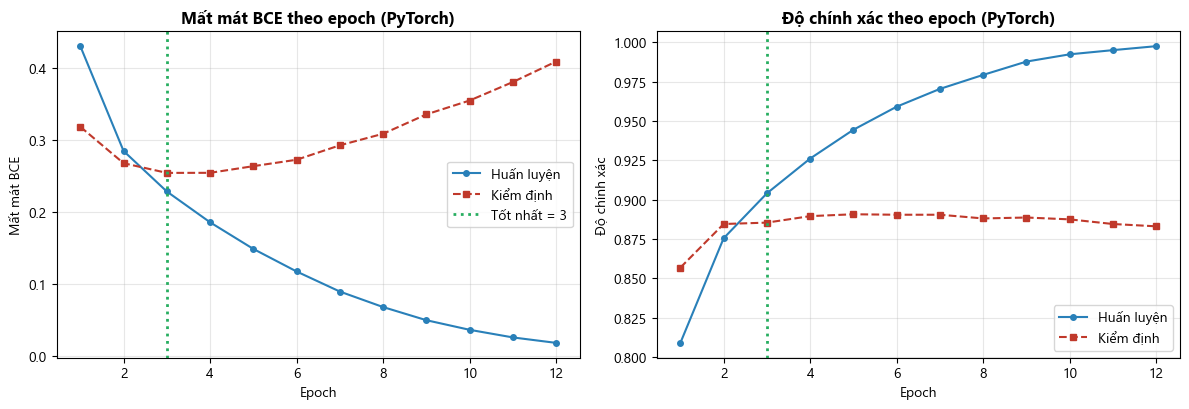

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
ep = np.arange(1, EPOCHS + 1)
axes[0].plot(ep, history["train_loss"], "o-", color="#2980b9", label="Huấn luyện", markersize=4)
axes[0].plot(ep, history["val_loss"], "s--", color="#c0392b", label="Kiểm định", markersize=4)
axes[0].axvline(best_epoch, color="#27ae60", linestyle=":", lw=2, label=f"Tốt nhất = {best_epoch}")
axes[0].set_title("Mất mát BCE theo epoch (PyTorch)", fontweight="bold")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Mất mát BCE")
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(ep, history["train_acc"], "o-", color="#2980b9", label="Huấn luyện", markersize=4)
axes[1].plot(ep, history["val_acc"], "s--", color="#c0392b", label="Kiểm định", markersize=4)
axes[1].axvline(best_epoch, color="#27ae60", linestyle=":", lw=2)
axes[1].set_title("Độ chính xác theo epoch (PyTorch)", fontweight="bold")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Độ chính xác")
axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Diễn giải hình.** Bảng bên trái tái hiện hình chữ U kinh điển của mất mát kiểm định: giảm nhanh
trong ba epoch đầu xuống đáy 0.2544, sau đó tăng đơn điệu lên 0.4091 ở epoch 12. Đường mất mát huấn
luyện giảm không ngừng về 0.0183. Khoảng cách giữa hai đường tại epoch 12 là 0.3908, so với chỉ
0.0258 tại epoch 3, tức là khoảng cách tổng quát hóa đã nở ra hơn mười lăm lần.

Bảng bên phải bổ sung một góc nhìn mà đường mất mát không cho thấy. Độ chính xác kiểm định tăng tới
0.8908 ở epoch 5 rồi đi ngang trong vùng 0.883 tới 0.891 suốt bảy epoch còn lại, gần như không suy
giảm, trong khi độ chính xác huấn luyện leo lên 0.9975. Hai đồ thị đặt cạnh nhau minh họa chính xác
luận điểm đã nêu ở notebook 01: quá khớp ở đây biểu hiện thành **sự tự tin thái quá** chứ không thành
sự sụp đổ của khả năng phân loại. Nếu chỉ theo dõi độ chính xác, người phân tích sẽ kết luận sai rằng
huấn luyện thêm không gây hại.

Đường chấm xanh lá tại epoch 3 cho thấy tiêu chí `val_loss` dừng sớm hơn đáng kể so với tiêu chí
`val_acc` (vốn sẽ chọn epoch 5). Báo cáo cố ý dùng tiêu chí khắt khe hơn để giữ mô hình ở vùng xác
suất được hiệu chuẩn tốt.

## 7. Lưu mô hình và kết quả trung gian

In [8]:
os.makedirs("../models", exist_ok=True)
torch.save(model.state_dict(), "../models/comments_cnn_pytorch.pt")
print("Đã lưu trọng số:", "../models/comments_cnn_pytorch.pt")

partial_pt = {
    "framework": "PyTorch",
    "params": int(N_PARAMS),
    "train_time_s": float(TRAIN_TIME),
    "epochs": int(EPOCHS),
    "best_epoch": int(best_epoch),
    **pt_metrics,
    "history": {k: [float(x) for x in v] for k, v in history.items()},
    "confusion_matrix": cm_pt.tolist(),
    "dataset": {"file": "womens_ecommerce_reviews.csv", "n_raw": int(N_RAW),
                "n_clean": int(N_CLEAN), "n_train": int(N_TRAIN),
                "n_val": int(N_VAL), "n_test": int(N_TEST), "n_features": int(MAX_LEN)},
}
with open(f"{REPORT_DIR}/_partial_pytorch.json", "w", encoding="utf-8") as f:
    json.dump(partial_pt, f, ensure_ascii=False, indent=2)
print("Đã ghi:", f"{REPORT_DIR}/_partial_pytorch.json")
print(json.dumps({k: v for k, v in partial_pt.items()
                  if k not in ("history", "dataset")}, indent=2, ensure_ascii=False))

Đã lưu trọng số: ../models/comments_cnn_pytorch.pt
Đã ghi: ../reports/_partial_pytorch.json
{
  "framework": "PyTorch",
  "params": 509665,
  "train_time_s": 23.931579113006592,
  "epochs": 12,
  "best_epoch": 3,
  "accuracy": 0.8804827789225788,
  "precision": 0.8991935483870968,
  "recall": 0.9618979151689432,
  "f1": 0.9294894060437652,
  "roc_auc": 0.9021426943241395,
  "loss": 0.2847144260995961,
  "confusion_matrix": [
    [
      315,
      300
    ],
    [
      106,
      2676
    ]
  ]
}


---

## 8. Kết luận notebook 02

Notebook đã tái hiện thành công kiến trúc 1D CNN bằng PyTorch và cung cấp điểm đối chứng độc lập cho
hiện thực NumPy thuần của notebook 01.

**Về đối chứng tính đúng đắn.** Ba bằng chứng hội tụ về cùng một kết luận. Số tham số trùng khớp
tuyệt đối ở 509 665. Quỹ đạo huấn luyện gần như trùng khít, với mất mát huấn luyện tại epoch 3 là
0.2286 ở cả hai hiện thực và cùng chọn epoch 3 làm epoch tốt nhất. Chỉ số cuối cùng chênh nhau không
quá 0.26 điểm phần trăm về accuracy. Vì hai hiện thực dùng hai cơ chế tính đạo hàm hoàn toàn khác
nhau, sự đồng thuận này rất khó xảy ra nếu lượt truyền ngược viết tay có lỗi.

**Về đối chứng hiệu năng.** PyTorch hoàn tất 12 epoch trong 23.9 giây so với 353.6 giây của NumPy,
nhanh hơn khoảng 14.8 lần trong lần đo này. Cái giá của việc tự viết mọi thứ là khoảng một bậc độ lớn
về thời gian, đổi lại là quyền kiểm soát và hiểu biết đầy đủ về từng phép tính.

**Về ranh giới giữa hiểu và dùng.** Bảng đối chiếu ở Mục 4 cho thấy mỗi tầng PyTorch đều có một công
thức tương ứng đã được dẫn bằng tay. Hai chi tiết mà chỉ người đã tự viết lại mới nhận ra là bố cục
tensor `(batch, kênh, độ dài)` đòi hỏi phép `transpose(1,2)`, và việc `BCEWithLogitsLoss` nhận logit
chính là thủ thuật ghép sigmoid với BCE để thu về đạo hàm rút gọn $(\hat y - y)/B$.

**Hạn chế còn lại.** Giống notebook 01, mô hình vẫn quá khớp từ epoch 4 và vẫn yếu trên lớp thiểu số
với recall chỉ 0.5122. Đây là hạn chế của kiến trúc và của hàm mất mát không trọng số, không phải của
framework, nên nó xuất hiện đồng đều ở cả ba cách hiện thực.

Kết quả của notebook đã được ghi vào `reports/_partial_pytorch.json` để notebook 01 đọc lại ở phần
tổng hợp, nơi ba hình so sánh và tệp `metrics_customer_comments.json` được dựng.